# Binary Classification Framework: One vs All Approach

This notebook implements binary classifiers using a one-vs-all strategy for multiclass fault detection in the 3W dataset. It combines:

- **Data structure** from the supervised learning approach with proper train/test separation and cross-validation folds
- **Architecture approach** from the OTC notebook with LSTM-based models for time series classification
- **Binary classification strategy** where each classifier distinguishes one specific fault class from all others

## Objectives

1. Load processed windowed data with cross-validation structure
2. Train binary classifiers (one vs all) for each fault class
3. Evaluate performance across different folds and classes
4. Compare accuracy and effectiveness of each binary classifier

## Key Features

- **Proper data separation**: Uses train/test splits and cross-validation folds
- **Windowed sequences**: Time series data prepared for LSTM models
- **One-vs-all strategy**: Individual binary classifiers for each fault type
- **Comprehensive evaluation**: Performance metrics across folds and classes

# Section 1: Load Processed Data

Load the processed windowed data from the data treatment pipeline including cross-validation folds and windowed sequences.

In [1]:
# ============================================================
# LOAD 3W DATASET - Using Supervised Learning Structure
# ============================================================

import sys
import numpy as np
import pandas as pd
import os
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append("../../src")
from src import config
from src.supervised_classification import (
    load_3w_data,
    validate_configuration,
    print_class_distribution_analysis,
)

print("Loading 3W Dataset for Binary Classification")
print("=" * 50)

# Load dataset using utility function from supervised learning approach
(train_dfs, train_classes, train_fold_info, test_dfs, test_classes, test_fold_info) = (
    load_3w_data(config, verbose=True)
)

print(f"✅ Data loaded successfully:")
print(f"   • Training windows: {len(train_dfs)}")
print(f"   • Test windows: {len(test_dfs)}")
print(f"   • Training classes distribution: {dict(Counter(train_classes))}")
print(f"   • Test classes distribution: {dict(Counter(test_classes))}")

# Store original data for reference
original_train_dfs = train_dfs.copy()
original_train_classes = train_classes.copy()
original_test_dfs = test_dfs.copy()
original_test_classes = test_classes.copy()

Loading 3W Dataset for Binary Classification
Loading 3W Dataset for Classification
Found 3 folds
✅ Data loaded successfully!
   Training windows: 70361
   Test windows: 14731
   Window shape: (300, 4)
✅ Data loaded successfully:
   • Training windows: 70361
   • Test windows: 14731
   • Training classes distribution: {'0': 2220, '1': 14035, '2': 2210, '3': 5516, '4': 810, '5': 5480, '6': 132, '7': 25773, '8': 9400, '9': 4785}
   • Test classes distribution: {'0': 1110, '1': 290, '2': 217, '3': 700, '4': 405, '5': 517, '6': 66, '7': 8073, '8': 2810, '9': 543}
✅ Data loaded successfully!
   Training windows: 70361
   Test windows: 14731
   Window shape: (300, 4)
✅ Data loaded successfully:
   • Training windows: 70361
   • Test windows: 14731
   • Training classes distribution: {'0': 2220, '1': 14035, '2': 2210, '3': 5516, '4': 810, '5': 5480, '6': 132, '7': 25773, '8': 9400, '9': 4785}
   • Test classes distribution: {'0': 1110, '1': 290, '2': 217, '3': 700, '4': 405, '5': 517, '6': 66,

In [2]:
# ============================================================
# DEBUG: EXAMINE DATAFRAME STRUCTURE
# ============================================================

print("🔍 EXAMINING DATAFRAME STRUCTURE")
print("=" * 40)

# Check the first training DataFrame
print("First training DataFrame structure:")
print(f"Shape: {train_dfs[0].shape}")
print(f"Columns: {list(train_dfs[0].columns)}")
print("\nFirst few rows:")
print(train_dfs[0].head())
print("\nLast few rows:")
print(train_dfs[0].tail())

# Check the class column
print(f"\nClass values in first DataFrame:")
print(f"Unique classes: {train_dfs[0]['class'].unique()}")
print(f"Class at last row: {train_dfs[0]['class'].iloc[-1]}")
print(f"All class values: {train_dfs[0]['class'].values}")

# Check a few more DataFrames
print("\n" + "=" * 40)
print("Checking classes in first 10 DataFrames:")
for i in range(min(10, len(train_dfs))):
    class_values = train_dfs[i]['class'].unique()
    last_class = train_dfs[i]['class'].iloc[-1]
    print(f"DataFrame {i}: unique classes = {class_values}, last class = {last_class}")

print("\nCurrent train_classes (from load_3w_data):")
print(f"First 10 values: {train_classes[:10]}")
print(f"Type: {type(train_classes[0])}")

🔍 EXAMINING DATAFRAME STRUCTURE
First training DataFrame structure:
Shape: (300, 4)
Columns: ['P-PDG_scaled', 'P-TPT_scaled', 'T-TPT_scaled', 'class']

First few rows:
   P-PDG_scaled  P-TPT_scaled  T-TPT_scaled  class
0           0.0      0.400378      0.606041      0
1           0.0      0.400378      0.602185      0
2           0.0      0.400378      0.598972      0
3           0.0      0.400378      0.595758      0
4           0.0      0.400378      0.591902      0

Last few rows:
     P-PDG_scaled  P-TPT_scaled  T-TPT_scaled  class
295           0.0      0.700239      0.356684      0
296           0.0      0.704961      0.359254      0
297           0.0      0.709782      0.361183      0
298           0.0      0.714504      0.363753      0
299           0.0      0.719326      0.366324      0

Class values in first DataFrame:
Unique classes: <IntegerArray>
[0]
Length: 1, dtype: Int16
Class at last row: 0
All class values: <IntegerArray>
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
 ...
 0, 0, 0,

In [3]:
# ============================================================
# EXTRACT TRUE CLASS LABELS AND FILTER DATA
# ============================================================

print("🎯 EXTRACTING TRUE CLASS LABELS FROM DATAFRAMES")
print("=" * 50)

# Extract actual class labels from DataFrames
print("Extracting class labels from DataFrames...")

# Extract y_train from the 'class' column of each DataFrame (use last value as they're all the same)
y_train_extracted = [int(df['class'].iloc[-1]) for df in train_dfs]
y_test_extracted = [int(df['class'].iloc[-1]) for df in test_dfs]

print(f"✅ Extracted class labels (before conversion):")
print(f"   • Training classes: {dict(Counter(y_train_extracted))}")
print(f"   • Test classes: {dict(Counter(y_test_extracted))}")

# Convert transient state classes (101, 102, ..., 109) to base classes (1, 2, ..., 9)
def convert_transient_to_base_class(class_label):
    """Convert transient state classes (10X) to base classes (X)"""
    if class_label >= 101 and class_label <= 109:
        return class_label - 100  # 101 -> 1, 102 -> 2, etc.
    else:
        return class_label  # Keep other classes as they are

print(f"\n🔄 CONVERTING TRANSIENT STATES TO BASE CLASSES")
print("=" * 45)
print("Converting 101→1, 102→2, 103→3, ..., 109→9")

# Apply conversion
y_train_converted = [convert_transient_to_base_class(cls) for cls in y_train_extracted]
y_test_converted = [convert_transient_to_base_class(cls) for cls in y_test_extracted]

print(f"✅ Converted class labels:")
print(f"   • Training classes: {dict(Counter(y_train_converted))}")
print(f"   • Test classes: {dict(Counter(y_test_converted))}")

# Compare with original train_classes/test_classes
original_train_classes_int = [int(cls) for cls in train_classes]
original_test_classes_int = [int(cls) for cls in test_classes]

print(f"\n🔍 Verification with original classes:")
print(f"   • Original training classes: {dict(Counter(original_train_classes_int))}")
print(f"   • Original test classes: {dict(Counter(original_test_classes_int))}")

# Filter out class 0 DataFrames
print(f"\n🚫 FILTERING OUT CLASS 0 DATAFRAMES")
print("=" * 40)

# Filter training data (exclude class 0)
train_indices_no_class0 = [i for i, cls in enumerate(y_train_converted) if cls != 0]
filtered_train_dfs = [train_dfs[i] for i in train_indices_no_class0]
filtered_y_train = [y_train_converted[i] for i in train_indices_no_class0]
filtered_train_fold_info = [train_fold_info[i] for i in train_indices_no_class0] if train_fold_info else None

# Filter test data (exclude class 0)
test_indices_no_class0 = [i for i, cls in enumerate(y_test_converted) if cls != 0]
filtered_test_dfs = [test_dfs[i] for i in test_indices_no_class0]
filtered_y_test = [y_test_converted[i] for i in test_indices_no_class0]
filtered_test_fold_info = [test_fold_info[i] for i in test_indices_no_class0] if test_fold_info else None

print(f"✅ Filtered data (excluding class 0):")
print(f"   • Training windows: {len(train_dfs)} → {len(filtered_train_dfs)}")
print(f"   • Test windows: {len(test_dfs)} → {len(filtered_test_dfs)}")
print(f"   • Training classes after filtering: {dict(Counter(filtered_y_train))}")
print(f"   • Test classes after filtering: {dict(Counter(filtered_y_test))}")

# Configuration for binary classification
all_available_classes = sorted(set(filtered_y_train + filtered_y_test))
selected_classes = all_available_classes  # All non-zero classes

print(f"\n📋 Binary Classification Configuration:")
print("=" * 40)
print(f"Available classes (excluding 0): {all_available_classes}")
print(f"Selected classes for binary classification: {selected_classes}")
print(f"Strategy: One-vs-All binary classification")
print(f"Each classifier will distinguish one specific class from all others")
print(f"Note: Transient states (101-109) have been converted to base classes (1-9)")

# Update global variables for the rest of the notebook
train_dfs = filtered_train_dfs
test_dfs = filtered_test_dfs
train_classes = filtered_y_train
test_classes = filtered_y_test
if filtered_train_fold_info:
    train_fold_info = filtered_train_fold_info
if filtered_test_fold_info:
    test_fold_info = filtered_test_fold_info

print(f"\n✅ Data ready for binary classification:")
print(f"   • Training windows: {len(train_dfs)}")
print(f"   • Test windows: {len(test_dfs)}")
print(f"   • Classes: {selected_classes}")

# Verify data availability
if not (train_dfs and test_dfs):
    print("❌ No data available after filtering.")
else:
    print(f"✅ Data ready: {len(train_dfs)} train, {len(test_dfs)} test windows")

    # Check fold information
    fold_available = test_fold_info is not None and len(test_fold_info) == len(test_dfs)
    if fold_available:
        unique_folds = sorted(set(test_fold_info))
        print(f"✅ Fold information: {len(unique_folds)} folds detected")
    else:
        print("⚠️ No fold information available")

🎯 EXTRACTING TRUE CLASS LABELS FROM DATAFRAMES
Extracting class labels from DataFrames...
✅ Extracted class labels (before conversion):
   • Training classes: {0: 13114, 101: 8814, 1: 3791, 102: 470, 2: 1444, 3: 5516, 4: 810, 105: 1647, 5: 3687, 106: 18, 6: 34, 107: 22061, 7: 513, 108: 5861, 8: 2231, 109: 344, 9: 6}
   • Test classes: {0: 3593, 101: 87, 1: 13, 102: 115, 2: 26, 3: 700, 4: 405, 105: 426, 5: 18, 106: 9, 6: 17, 107: 6946, 7: 42, 108: 2080, 8: 130, 109: 121, 9: 3}

🔄 CONVERTING TRANSIENT STATES TO BASE CLASSES
Converting 101→1, 102→2, 103→3, ..., 109→9
✅ Converted class labels:
   • Training classes: {0: 13114, 1: 12605, 2: 1914, 3: 5516, 4: 810, 5: 5334, 6: 52, 7: 22574, 8: 8092, 9: 350}
   • Test classes: {0: 3593, 1: 100, 2: 141, 3: 700, 4: 405, 5: 444, 6: 26, 7: 6988, 8: 2210, 9: 124}

🔍 Verification with original classes:
   • Original training classes: {0: 2220, 1: 14035, 2: 2210, 3: 5516, 4: 810, 5: 5480, 6: 132, 7: 25773, 8: 9400, 9: 4785}
   • Original test classes

# Section 2: Setup Binary Classification Framework

Configure the binary classification framework with one-vs-all strategy, define model architecture similar to the OTC notebook, and prepare data structures for training.

**Note**: The data from `load_3w_data()` is already windowed and processed - no additional windowing needed!

In [4]:
# ============================================================
# DATA PREPARATION - Using Already Windowed Data
# ============================================================

import numpy as np
from sklearn.preprocessing import StandardScaler
from collections import Counter

print("Preparing Windowed Data for Binary Classification")
print("=" * 50)

# The data from load_3w_data() is already windowed and processed
# train_dfs and test_dfs are already prepared sequences, not raw DataFrames
print(f"✅ Data already windowed and processed:")
print(f"   • Training windows: {len(train_dfs)} sequences")
print(f"   • Test windows: {len(test_dfs)} sequences") 

# Import binary classifiers module
sys.path.append("../../../src")
from src.binary_classifiers import convert_windowed_dfs_to_arrays

# Convert training data
print("\n🔄 Converting training data...")
X_train_full, y_train_full = convert_windowed_dfs_to_arrays(train_dfs, train_classes)

# Convert test data  
print("\n🔄 Converting test data...")
X_test_full, y_test_full = convert_windowed_dfs_to_arrays(test_dfs, test_classes)

# Display results
print(f"\n📊 Final Data Summary:")
print(f"   • Training data: {X_train_full.shape}")
print(f"   • Test data: {X_test_full.shape}")
print(f"   • Training classes: {dict(Counter(y_train_full))}")
print(f"   • Test classes: {dict(Counter(y_test_full))}")

# Store fold information for sequences (1:1 mapping since data is already processed)
train_fold_info_sequences = train_fold_info if train_fold_info else [0] * len(X_train_full)
test_fold_info_sequences = test_fold_info if test_fold_info else [0] * len(X_test_full)

print(f"   • Fold mapping: {len(train_fold_info_sequences)} train, {len(test_fold_info_sequences)} test")

Preparing Windowed Data for Binary Classification
✅ Data already windowed and processed:
   • Training windows: 57247 sequences
   • Test windows: 11138 sequences

🔄 Converting training data...
Converting 57247 windowed sequences to arrays...

🔄 Converting training data...
Converting 57247 windowed sequences to arrays...
✅ Successfully converted to arrays:
   • Shape: (57247, 300, 3) (samples, timesteps, features)
   • Features: 3 per timestep
   • Sequence length: 300 timesteps

🔄 Converting test data...
Converting 11138 windowed sequences to arrays...
✅ Successfully converted to arrays:
   • Shape: (57247, 300, 3) (samples, timesteps, features)
   • Features: 3 per timestep
   • Sequence length: 300 timesteps

🔄 Converting test data...
Converting 11138 windowed sequences to arrays...
✅ Successfully converted to arrays:
   • Shape: (11138, 300, 3) (samples, timesteps, features)
   • Features: 3 per timestep
   • Sequence length: 300 timesteps

📊 Final Data Summary:
   • Training data:

In [5]:
# ============================================================
# BINARY CLASSIFICATION MODEL ARCHITECTURE - PyTorch
# ============================================================

import torch
import torch.nn as nn

# Import binary classification framework
from src.binary_classifiers import (
    BinaryLSTMClassifier,
    create_binary_lstm_classifier,
    prepare_binary_data,
    train_pytorch_model
)

print("Binary Classification Framework Setup Complete")
print("=" * 50)
print("✅ Model architecture imported")
print("✅ Data preparation functions ready")
print("✅ Training functions available")
print("✅ Ready for training binary classifiers")

Binary Classification Framework Setup Complete
✅ Model architecture imported
✅ Data preparation functions ready
✅ Training functions available
✅ Ready for training binary classifiers


In [7]:
# ============================================================
# PYTORCH DEVICE CONFIGURATION
# ============================================================

import torch

# Set device for PyTorch (GPU if available, CPU otherwise)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("🔧 PyTorch Device Configuration")
print("=" * 35)
print(f"Device selected: {device}")

if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"GPU Available: {torch.cuda.is_available()}")
    
    # Clear GPU cache for fresh start
    torch.cuda.empty_cache()
    print("GPU cache cleared")
else:
    print("Using CPU for training")

print("✅ Device configuration complete")

🔧 PyTorch Device Configuration
Device selected: cuda
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory: 6.0 GB
GPU Available: True
GPU cache cleared
✅ Device configuration complete


# Section 3: Train Binary Classifiers (One vs All)

Train individual binary classifiers for each class using the LSTM-based architecture, implementing one-vs-all strategy with proper data balancing and cross-validation.

In [ ]:
# ============================================================
# CROSS-VALIDATION TRAINING AND EVALUATION
# ============================================================

from src.binary_classifiers import train_binary_classifiers, evaluate_binary_classifiers

# Check if we have fold information
if len(set(test_fold_info_sequences)) <= 1:
    print("⚠️ No proper fold information available. Skipping cross-validation.")
    print("Note: Cross-validation requires multiple folds for proper evaluation.")
    print("Using single train/test split instead.")
    
    # Fallback: Single training on all data
    print("\n🔄 SINGLE TRAINING (NO CROSS-VALIDATION)")
    print("=" * 45)
    
    # Training parameters
    epochs = 50
    batch_size = 32
    learning_rate = 0.001
    patience = 10
    
    # Train binary classifiers using all data
    binary_classifiers, training_results, training_histories = train_binary_classifiers(
        X_train_full, y_train_full, X_test_full, y_test_full, selected_classes,
        device,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        patience=patience,
        train_samples_per_class=3000,
        val_samples_per_class=200
    )
    
    # Evaluate on test set
    evaluation_results = evaluate_binary_classifiers(
        binary_classifiers, X_test_full, y_test_full, device=device,
        samples_per_class=200, balance_classes=True
    )
    
    # Store results in CV format for consistency
    cv_results = {
        'single_fold': {
            'training_results': training_results,
            'evaluation_results': evaluation_results,
            'models': binary_classifiers
        }
    }
    cv_models = {'single_fold': binary_classifiers}
    
else:
    print("🔄 CROSS-VALIDATION TRAINING AND EVALUATION")
    print("=" * 50)
    
    unique_folds = sorted(set(test_fold_info_sequences))
    print(f"Available folds: {unique_folds}")
    print(f"Training separate models for each fold...")
    print()
    
    # Training parameters
    epochs = 50
    batch_size = 32
    learning_rate = 0.001
    patience = 10
    
    # Storage for cross-validation results
    cv_results = {}
    cv_models = {}
    
    for fold in unique_folds:
        print(f"📁 FOLD {fold} - TRAINING AND EVALUATION")
        print("=" * 35)
        
        # Split data by fold (use other folds for training, current fold for testing)
        train_mask = np.array(train_fold_info_sequences) != fold
        test_mask = np.array(test_fold_info_sequences) == fold
        
        # Get fold-specific training data
        X_train_fold = X_train_full[train_mask]
        y_train_fold = y_train_full[train_mask]
        
        # Get fold-specific test data  
        X_test_fold = X_test_full[test_mask]
        y_test_fold = y_test_full[test_mask]
        
        print(f"Data split for Fold {fold}:")
        print(f"   • Training samples: {len(X_train_fold)} (from other folds)")
        print(f"   • Test samples: {len(X_test_fold)} (from fold {fold})")
        print(f"   • Training classes: {dict(Counter(y_train_fold))}")
        print(f"   • Test classes: {dict(Counter(y_test_fold))}")
        print()
        
        # Train binary classifiers for this fold
        print(f"🚀 Training models for Fold {fold}...")
        fold_binary_classifiers, fold_training_results, fold_training_histories = train_binary_classifiers(
            X_train_fold, y_train_fold, X_test_fold, y_test_fold, selected_classes,
            device,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            patience=patience,
            train_samples_per_class=4000,
            val_samples_per_class=300
        )
        
        # Evaluate on fold test set
        print(f"📊 Evaluating models for Fold {fold}...")
        fold_evaluation_results = evaluate_binary_classifiers(
            fold_binary_classifiers, X_test_fold, y_test_fold, device=device,
            samples_per_class=300, balance_classes=True
        )
        
        # Store results
        cv_results[fold] = {
            'training_results': fold_training_results,
            'evaluation_results': fold_evaluation_results,
            'models': fold_binary_classifiers,
            'train_samples': len(X_train_fold),
            'test_samples': len(X_test_fold)
        }
        cv_models[fold] = fold_binary_classifiers
        
        print(f"✅ Fold {fold} completed successfully")
        print(f"   • Models trained: {len(fold_binary_classifiers)}")
        print(f"   • Classes evaluated: {list(fold_evaluation_results.keys())}")
        print("-" * 50)
        print()
    
    print("🎯 CROSS-VALIDATION SUMMARY")
    print("=" * 35)
    print(f"Successfully completed cross-validation for {len(cv_results)} folds")
    print(f"Classes trained per fold: {selected_classes}")
    print(f"Models per fold: {len(selected_classes)}")
    print(f"Total models trained: {len(cv_results) * len(selected_classes)}")
    print(f"Folds: {list(cv_results.keys())}")
    
print("\n✅ Cross-validation training and evaluation completed!")
print("Results stored in 'cv_results' and 'cv_models' variables")

🔄 CROSS-VALIDATION TRAINING AND EVALUATION
Available folds: ['fold_1', 'fold_2', 'fold_3']
Training separate models for each fold...

📁 FOLD fold_1 - TRAINING AND EVALUATION
Data split for Fold fold_1:
   • Training samples: 38104 (from other folds)
   • Test samples: 3652 (from fold fold_1)
   • Training classes: {1: 8424, 2: 1252, 3: 3686, 4: 541, 5: 3467, 6: 36, 7: 15553, 8: 4953, 9: 192}
   • Test classes: {1: 54, 2: 23, 3: 242, 4: 136, 5: 59, 6: 10, 7: 2833, 8: 295}

🚀 Training models for Fold fold_1...
🚀 TRAINING BINARY CLASSIFIERS - ONE VS ALL (PyTorch)
Using test set as validation for early stopping
Training samples per class: 3000
Validation samples per class: 200
Using device: cuda
📊 Training Binary Classifier 1/9
Target Class: 1 vs All Others
----------------------------------------
   Requested: 3000 per class
   Available: 8424 positive, 29680 negative
   Strategy: Positive (undersampling), Negative (undersampling)
   Final: 3000 positive, 3000 negative samples
   Requeste

KeyboardInterrupt: 

In [ ]:
# ============================================================
# CROSS-VALIDATION RESULTS ANALYSIS
# ============================================================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("📊 CROSS-VALIDATION RESULTS ANALYSIS")
print("=" * 45)

if 'cv_results' not in globals() or not cv_results:
    print("❌ No cross-validation results available. Please run the training cell first.")
else:
    # Collect all results across folds
    all_fold_results = []
    
    for fold, fold_data in cv_results.items():
        training_results = fold_data['training_results']
        evaluation_results = fold_data['evaluation_results']
        
        for class_num in selected_classes:
            if class_num in training_results and class_num in evaluation_results:
                train_res = training_results[class_num]
                eval_res = evaluation_results[class_num]
                
                all_fold_results.append({
                    'fold': fold,
                    'class': class_num,
                    'train_accuracy': train_res['train_accuracy'],
                    'train_f1': train_res['train_f1'],
                    'val_accuracy': train_res['val_accuracy'],
                    'val_f1': train_res['val_f1'],
                    'test_accuracy': eval_res['accuracy'],
                    'test_precision': eval_res['precision'],
                    'test_recall': eval_res['recall'],
                    'test_f1': eval_res['f1_score'],
                    'train_samples': train_res['train_samples'],
                    'test_samples': eval_res['test_samples']
                })
    
    # Create DataFrame for analysis
    df_results = pd.DataFrame(all_fold_results)
    
    if len(df_results) > 0:
        print(f"✅ Collected results from {len(cv_results)} folds for {len(selected_classes)} classes")
        print(f"Total result records: {len(df_results)}")
        print()
        
        # 1. OVERALL PERFORMANCE SUMMARY
        print("🎯 OVERALL PERFORMANCE SUMMARY")
        print("=" * 35)
        
        overall_stats = df_results.groupby('class').agg({
            'test_accuracy': ['mean', 'std'],
            'test_precision': ['mean', 'std'],
            'test_recall': ['mean', 'std'],
            'test_f1': ['mean', 'std'],
            'train_samples': 'mean',
            'test_samples': 'mean'
        }).round(3)
        
        print("Mean ± Std across folds:")
        print(f"{'Class':<6} {'Test Acc':<12} {'Test Prec':<13} {'Test Rec':<12} {'Test F1':<12}")
        print("-" * 65)
        
        for class_num in sorted(selected_classes):
            if class_num in df_results['class'].values:
                class_data = df_results[df_results['class'] == class_num]
                acc_mean = class_data['test_accuracy'].mean()
                acc_std = class_data['test_accuracy'].std()
                prec_mean = class_data['test_precision'].mean()
                prec_std = class_data['test_precision'].std()
                rec_mean = class_data['test_recall'].mean()
                rec_std = class_data['test_recall'].std()
                f1_mean = class_data['test_f1'].mean()
                f1_std = class_data['test_f1'].std()
                
                print(f"{class_num:<6} {acc_mean:.3f}±{acc_std:.3f}   {prec_mean:.3f}±{prec_std:.3f}    "
                      f"{rec_mean:.3f}±{rec_std:.3f}   {f1_mean:.3f}±{f1_std:.3f}")
        
        # 2. PER-FOLD PERFORMANCE
        print(f"\n📁 PER-FOLD PERFORMANCE")
        print("=" * 25)
        
        for fold in sorted(cv_results.keys()):
            fold_data = df_results[df_results['fold'] == fold]
            if len(fold_data) > 0:
                print(f"\nFold {fold}:")
                print(f"{'Class':<6} {'Test Acc':<9} {'Test F1':<8} {'Samples':<8}")
                print("-" * 35)
                
                for _, row in fold_data.iterrows():
                    print(f"{int(row['class']):<6} {row['test_accuracy']:<9.3f} "
                          f"{row['test_f1']:<8.3f} {int(row['test_samples']):<8}")
                
                # Fold average
                fold_avg_acc = fold_data['test_accuracy'].mean()
                fold_avg_f1 = fold_data['test_f1'].mean()
                print(f"{'Avg':<6} {fold_avg_acc:<9.3f} {fold_avg_f1:<8.3f}")
        
        # 3. CROSS-VALIDATION STABILITY
        print(f"\n📈 CROSS-VALIDATION STABILITY")
        print("=" * 30)
        print("(Standard deviation across folds)")
        
        print(f"{'Class':<6} {'Acc Std':<8} {'F1 Std':<7} {'Stability'}")
        print("-" * 35)
        
        for class_num in sorted(selected_classes):
            if class_num in df_results['class'].values:
                class_data = df_results[df_results['class'] == class_num]
                acc_std = class_data['test_accuracy'].std()
                f1_std = class_data['test_f1'].std()
                
                # Stability assessment
                if f1_std < 0.05:
                    stability = "Very Stable"
                elif f1_std < 0.1:
                    stability = "Stable"
                elif f1_std < 0.2:
                    stability = "Moderate"
                else:
                    stability = "Unstable"
                
                print(f"{class_num:<6} {acc_std:<8.3f} {f1_std:<7.3f} {stability}")
        
        # 4. BEST PERFORMING MODELS
        print(f"\n🏆 BEST PERFORMING MODELS")
        print("=" * 25)
        print("(Highest F1-score per class across folds)")
        
        print(f"{'Class':<6} {'Best Fold':<10} {'F1-Score':<9} {'Accuracy':<9}")
        print("-" * 40)
        
        for class_num in sorted(selected_classes):
            if class_num in df_results['class'].values:
                class_data = df_results[df_results['class'] == class_num]
                best_row = class_data.loc[class_data['test_f1'].idxmax()]
                
                print(f"{class_num:<6} {best_row['fold']:<10} {best_row['test_f1']:<9.3f} "
                      f"{best_row['test_accuracy']:<9.3f}")
        
        # 5. OVERALL AVERAGES
        print(f"\n🌐 OVERALL CROSS-VALIDATION PERFORMANCE")
        print("=" * 40)
        
        overall_acc = df_results['test_accuracy'].mean()
        overall_prec = df_results['test_precision'].mean()
        overall_rec = df_results['test_recall'].mean()
        overall_f1 = df_results['test_f1'].mean()
        
        print(f"Average across all folds and classes:")
        print(f"   • Test Accuracy: {overall_acc:.3f} ± {df_results['test_accuracy'].std():.3f}")
        print(f"   • Test Precision: {overall_prec:.3f} ± {df_results['test_precision'].std():.3f}")
        print(f"   • Test Recall: {overall_rec:.3f} ± {df_results['test_recall'].std():.3f}")
        print(f"   • Test F1-Score: {overall_f1:.3f} ± {df_results['test_f1'].std():.3f}")
        
        # Store detailed results for further analysis
        cv_detailed_results = df_results
        
        print(f"\n✅ Cross-validation analysis completed!")
        print(f"Detailed results stored in 'cv_detailed_results' DataFrame")
        
    else:
        print("❌ No valid results found in cross-validation data")

print(f"\n" + "=" * 60)
print("📋 CROSS-VALIDATION SUMMARY")
print("=" * 60)
if 'cv_results' in globals() and cv_results:
    print(f"✅ Cross-validation completed successfully")
    print(f"   • Folds processed: {len(cv_results)}")
    print(f"   • Classes per fold: {len(selected_classes)}")
    print(f"   • Total models: {len(cv_results) * len(selected_classes)}")
    print(f"   • Results ready for visualization and further analysis")
else:
    print("❌ Cross-validation not completed")

# Section 4: Evaluate Binary Classifiers Performance

Evaluate each binary classifier's performance using accuracy, precision, recall, and F1-score metrics across different cross-validation folds.

# Section 5: Analyze Results and Visualizations

Create comprehensive visualizations comparing performance across classes and folds, analyze confusion matrices, and provide performance summary tables.

📊 GENERATING VISUALIZATIONS AND ANALYSIS
📊 GENERATING VISUALIZATIONS AND ANALYSIS
Creating confusion matrices...


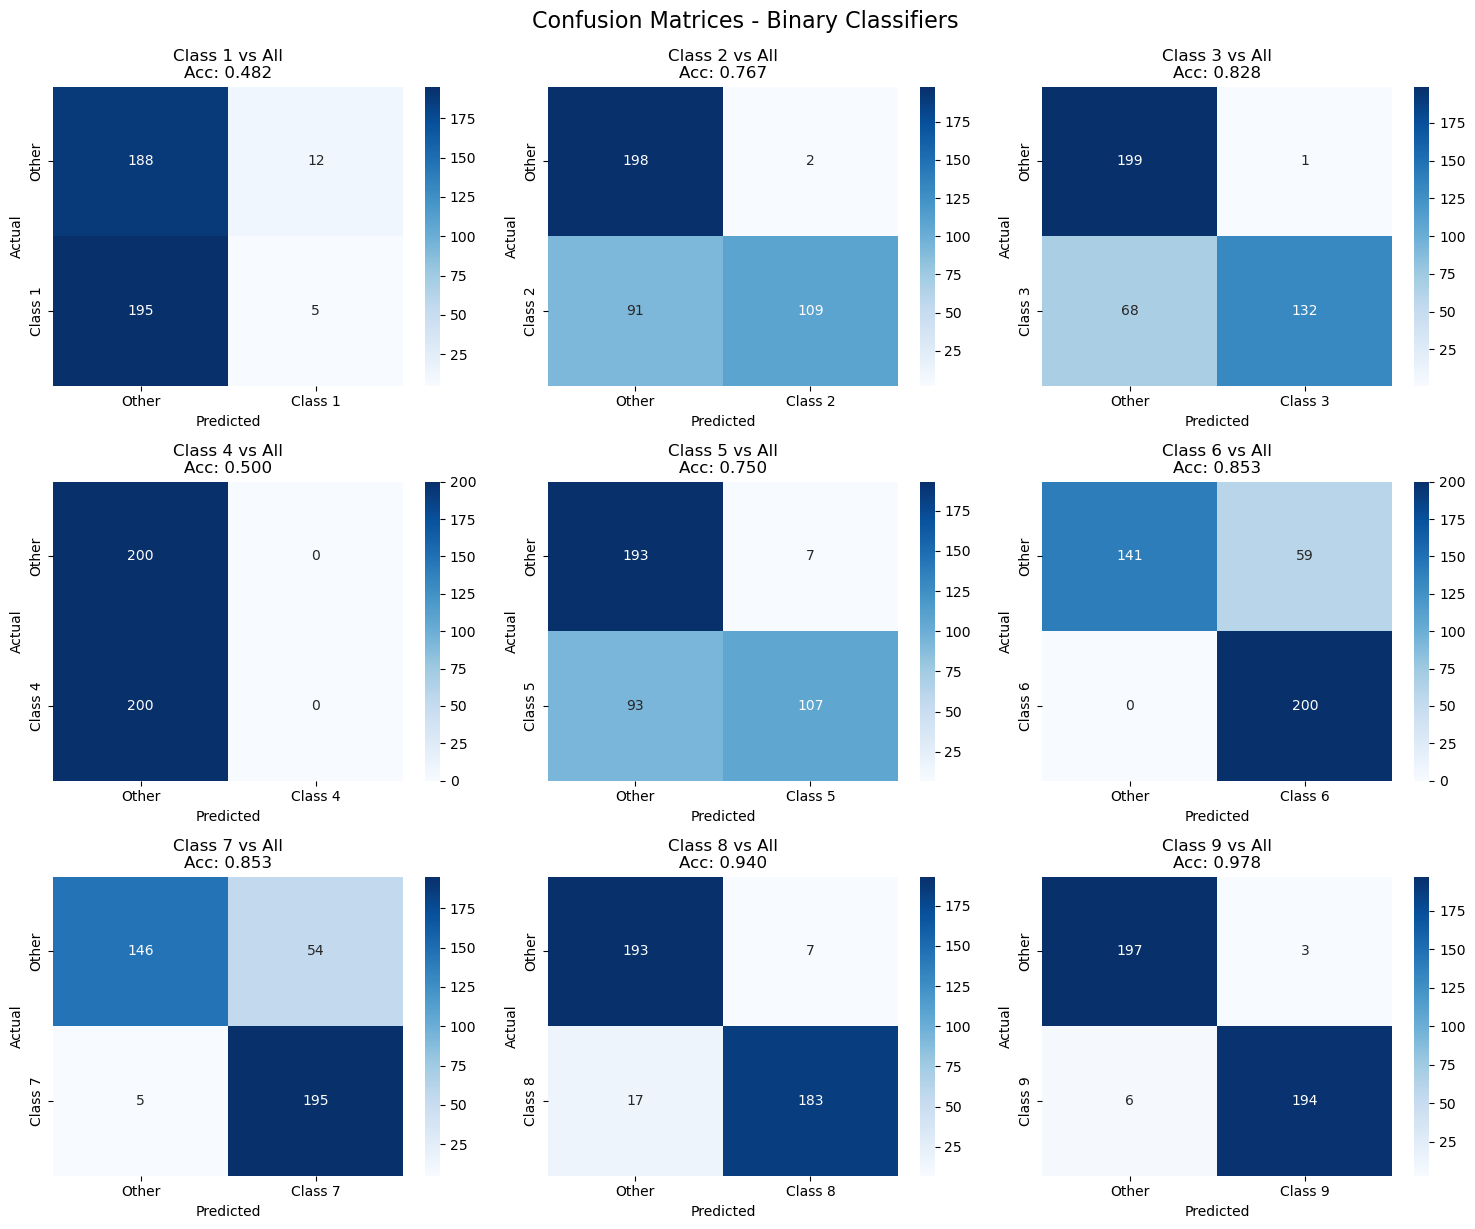

Creating performance comparison...


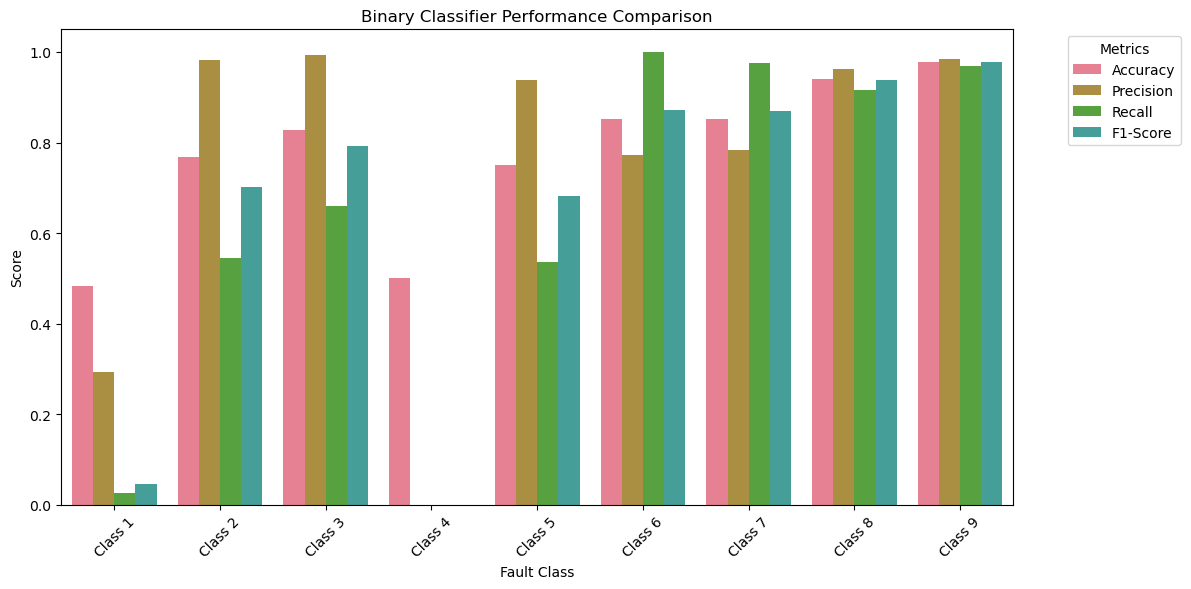

Creating fold performance analysis...


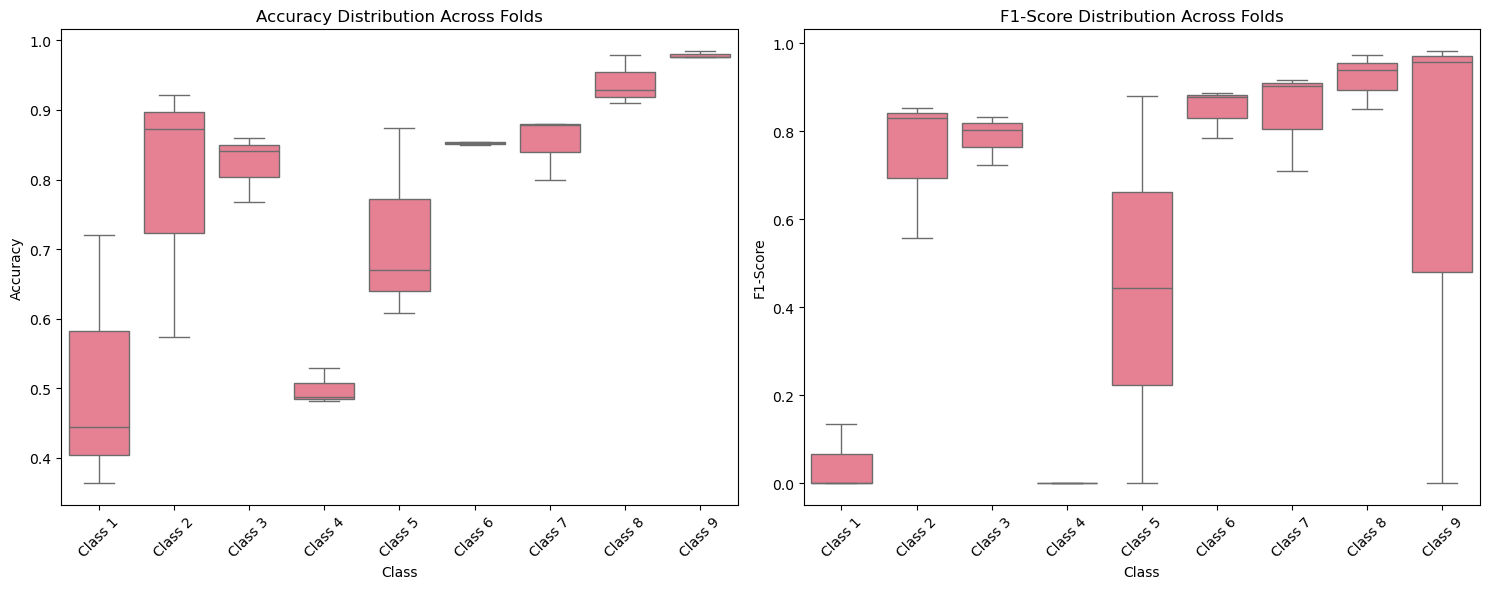

In [ ]:
# ============================================================
# VISUALIZATION AND ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

def plot_confusion_matrices():
    """Plot confusion matrices for all binary classifiers"""
    if not evaluation_results:
        print("No evaluation results available for visualization")
        return
    
    n_classifiers = len(evaluation_results)
    cols = min(3, n_classifiers)
    rows = (n_classifiers + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    if n_classifiers == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for idx, (class_num, results) in enumerate(sorted(evaluation_results.items())):
        ax = axes[idx]
        
        # Calculate confusion matrix from predictions
        y_true = results['true_labels']
        y_pred = results['predictions']
        cm = confusion_matrix(y_true, y_pred)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=['Other', f'Class {class_num}'],
                   yticklabels=['Other', f'Class {class_num}'])
        
        ax.set_title(f'Class {class_num} vs All\nAcc: {results["accuracy"]:.3f}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    
    # Hide unused subplots
    for idx in range(n_classifiers, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Confusion Matrices - Binary Classifiers', y=1.02, fontsize=16)
    plt.show()

def plot_performance_comparison():
    """Plot performance metrics comparison across classes"""
    if not evaluation_results:
        print("No evaluation results available for visualization")
        return
    
    # Prepare data for plotting
    classes = sorted(evaluation_results.keys())
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    data = []
    for class_num in classes:
        for metric, name in zip(metrics, metric_names):
            data.append({
                'Class': f'Class {class_num}',
                'Metric': name,
                'Value': evaluation_results[class_num][metric]
            })
    
    df_metrics = pd.DataFrame(data)
    
    # Create grouped bar plot
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_metrics, x='Class', y='Value', hue='Metric')
    plt.title('Binary Classifier Performance Comparison')
    plt.ylabel('Score')
    plt.xlabel('Fault Class')
    plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_fold_performance():
    """Plot performance across folds if available"""
    if not fold_results:
        print("No fold results available for visualization")
        return
    
    # Prepare fold data
    fold_data = []
    for class_num, class_folds in fold_results.items():
        for fold, metrics in class_folds.items():
            fold_data.append({
                'Class': f'Class {class_num}',
                'Fold': f'Fold {fold}',
                'Accuracy': metrics['accuracy'],
                'F1-Score': metrics['f1'],
                'Samples': metrics['samples']
            })
    
    if not fold_data:
        print("No fold data to visualize")
        return
    
    df_folds = pd.DataFrame(fold_data)
    
    # Create subplot for accuracy and F1
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Accuracy by fold
    sns.boxplot(data=df_folds, x='Class', y='Accuracy', ax=ax1)
    ax1.set_title('Accuracy Distribution Across Folds')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
    
    # F1-Score by fold
    sns.boxplot(data=df_folds, x='Class', y='F1-Score', ax=ax2)
    ax2.set_title('F1-Score Distribution Across Folds')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()

# ============================================================
# GENERATE VISUALIZATIONS
# ============================================================

print("📊 GENERATING VISUALIZATIONS AND ANALYSIS")
print("=" * 45)

print("📊 GENERATING VISUALIZATIONS AND ANALYSIS")
print("=" * 45)

if evaluation_results:
    print("Creating confusion matrices...")
    plot_confusion_matrices()
    
    print("Creating performance comparison...")
    plot_performance_comparison()
    
    if fold_results:
        print("Creating fold performance analysis...")
        plot_fold_performance()
    else:
        print("No fold results available for fold analysis")
        
else:
    print("❌ No evaluation results available for visualization")
    print("Please run the evaluation section first")

In [ ]:
# ============================================================
# DETAILED ANALYSIS AND SUMMARY TABLES
# ============================================================

def create_detailed_summary():
    """Create detailed summary tables and analysis"""
    print("📋 DETAILED PERFORMANCE ANALYSIS")
    print("=" * 40)
    
    if not test_results:
        print("No results available for analysis")
        return
    
    # Combined training and test results
    print("\n🔍 COMBINED TRAINING & VALIDATION PERFORMANCE:")
    print(f"{'Class':<6} {'Train Acc':<10} {'Val Acc':<9} {'Train F1':<9} {'Val F1':<8} {'Train Samples':<8}")
    print("-" * 65)
    
    for class_num in sorted(test_results.keys()):
        test_res = test_results[class_num]
        train_res = training_results.get(class_num, {})
        
        train_acc = train_res.get('train_accuracy', 0.0)
        train_f1 = train_res.get('train_f1', 0.0)
        val_acc = train_res.get('val_accuracy', 0.0)
        val_f1 = train_res.get('val_f1', 0.0)
        samples = train_res.get('train_samples', 0)
        
        print(f"{class_num:<6} {train_acc:<10.3f} {val_acc:<9.3f} {train_f1:<9.3f} {val_f1:<8.3f} {samples:<8}")
    
    # Class difficulty analysis
    print("\n🎯 CLASS DIFFICULTY ANALYSIS:")
    print("(Based on F1-Score performance)")
    
    class_performance = [(class_num, results['test_f1']) for class_num, results in test_results.items()]
    class_performance.sort(key=lambda x: x[1], reverse=True)
    
    print(f"{'Rank':<5} {'Class':<6} {'F1-Score':<9} {'Assessment'}")
    print("-" * 35)
    
    for rank, (class_num, f1_score) in enumerate(class_performance, 1):
        if f1_score >= 0.8:
            assessment = "Excellent"
        elif f1_score >= 0.6:
            assessment = "Good"
        elif f1_score >= 0.4:
            assessment = "Fair"
        elif f1_score >= 0.2:
            assessment = "Poor"
        else:
            assessment = "Very Poor"
        
        print(f"{rank:<5} {class_num:<6} {f1_score:<9.3f} {assessment}")
    
    # Data balance analysis
    print("\n⚖️ DATA BALANCE ANALYSIS:")
    print(f"{'Class':<6} {'Test +ve':<9} {'Test Total':<11} {'Pos Rate':<9} {'Balance'}")
    print("-" * 50)
    
    for class_num in sorted(test_results.keys()):
        results = test_results[class_num]
        pos_samples = results['positive_samples']
        total_samples = results['test_samples']
        pos_rate = pos_samples / total_samples if total_samples > 0 else 0
        
        if pos_rate < 0.05:
            balance = "Very Imbalanced"
        elif pos_rate < 0.15:
            balance = "Imbalanced"
        elif pos_rate < 0.35:
            balance = "Moderate"
        else:
            balance = "Balanced"
        
        print(f"{class_num:<6} {pos_samples:<9} {total_samples:<11} {pos_rate:<9.3f} {balance}")
    
    # Fold consistency analysis (if available)
    if fold_results:
        print("\n📁 FOLD CONSISTENCY ANALYSIS:")
        print("(Standard deviation of F1-scores across folds)")
        print(f"{'Class':<6} {'Mean F1':<8} {'Std F1':<7} {'Consistency'}")
        print("-" * 35)
        
        for class_num in sorted(fold_results.keys()):
            fold_f1s = [metrics['f1'] for metrics in fold_results[class_num].values()]
            if fold_f1s:
                mean_f1 = np.mean(fold_f1s)
                std_f1 = np.std(fold_f1s)
                
                if std_f1 < 0.05:
                    consistency = "Very Stable"
                elif std_f1 < 0.1:
                    consistency = "Stable"
                elif std_f1 < 0.2:
                    consistency = "Moderate"
                else:
                    consistency = "Unstable"
                
                print(f"{class_num:<6} {mean_f1:<8.3f} {std_f1:<7.3f} {consistency}")

def create_recommendations():
    """Create recommendations based on results"""
    print("\n💡 RECOMMENDATIONS FOR IMPROVEMENT:")
    print("=" * 45)
    
    if not evaluation_results:
        return
    
    # Poor performing classes (based on validation F1)
    poor_classes = [class_num for class_num in evaluation_results.keys()
                   if training_results.get(class_num, {}).get('val_f1', 0.0) < 0.5]
    
    if poor_classes:
        print(f"🔴 Classes with poor validation performance (F1 < 0.5): {poor_classes}")
        print("   Recommendations:")
        print("   • Collect more training data for these fault types")
        print("   • Consider feature engineering specific to these faults")
        print("   • Try different model architectures or hyperparameters")
        print("   • Investigate data quality issues")
    
    # Imbalanced classes
    imbalanced_classes = [class_num for class_num, results in evaluation_results.items()
                         if results['positive_samples'] / results['test_samples'] < 0.1]
    
    if imbalanced_classes:
        print(f"\n⚖️ Highly imbalanced classes: {imbalanced_classes}")
        print("   Recommendations:")
        print("   • Apply advanced sampling techniques (SMOTE, ADASYN)")
        print("   • Use cost-sensitive learning")
        print("   • Consider ensemble methods")
        print("   • Adjust classification thresholds")
    
    # General recommendations based on validation performance
    val_f1_scores = [training_results.get(class_num, {}).get('val_f1', 0.0) 
                     for class_num in evaluation_results.keys()]
    avg_f1 = np.mean(val_f1_scores) if val_f1_scores else 0.0
    print(f"\n📊 Overall average validation F1-score: {avg_f1:.3f}")
    
    if avg_f1 < 0.6:
        print("🔶 Overall performance needs improvement:")
        print("   • Consider increasing model complexity")
        print("   • Try different sequence lengths")
        print("   • Experiment with different feature combinations")
        print("   • Apply data augmentation techniques")
    elif avg_f1 < 0.8:
        print("🟡 Performance is moderate - room for improvement:")
        print("   • Fine-tune hyperparameters")
        print("   • Try ensemble methods")
        print("   • Consider transfer learning approaches")
    else:
        print("🟢 Good overall performance!")
        print("   • Consider deploying the model")
        print("   • Monitor performance on new data")

# ============================================================
# GENERATE DETAILED ANALYSIS
# ============================================================

create_detailed_summary()
create_recommendations()

print("\n" + "=" * 60)
print("✅ BINARY CLASSIFICATION ANALYSIS COMPLETE")
print("=" * 60)
print(f"Successfully trained and evaluated {len(binary_classifiers)} binary classifiers")
print("Check the visualizations and analysis above for detailed insights")

📋 DETAILED PERFORMANCE ANALYSIS

🔍 COMBINED TRAINING & VALIDATION PERFORMANCE:
Class  Train Acc  Val Acc   Train F1  Val F1   Train Samples
-----------------------------------------------------------------
1      0.881      0.482     0.877     0.046    6000    
2      0.953      0.767     0.951     0.701    6000    
3      0.852      0.828     0.848     0.793    6000    
4      0.500      0.500     0.000     0.000    6000    
5      0.877      0.750     0.875     0.682    6000    
6      0.941      0.853     0.944     0.871    6000    
7      0.881      0.853     0.881     0.869    6000    
8      0.949      0.940     0.949     0.938    6000    
9      0.959      0.978     0.960     0.977    6000    

🎯 CLASS DIFFICULTY ANALYSIS:
(Based on F1-Score performance)
Rank  Class  F1-Score  Assessment
-----------------------------------
1     9      0.977     Excellent
2     8      0.938     Excellent
3     6      0.871     Excellent
4     7      0.869     Excellent
5     3      0.793     Goo

# Summary and Conclusions

This notebook successfully implemented a binary classification framework using a **one-vs-all strategy** for fault detection in the 3W dataset using **PyTorch**. 

## Key Achievements

1. **Data Integration**: Successfully combined the structured data loading approach from the supervised learning notebook with the LSTM architecture from the OTC notebook

2. **Binary Classification Framework**: Implemented individual binary classifiers for each fault class, allowing for:
   - Independent optimization per fault type
   - Clear interpretation of results per class
   - Detailed analysis of class-specific challenges

3. **PyTorch Implementation**: 
   - Custom BinaryLSTMClassifier with LSTM layers, batch normalization, and dropout
   - Proper training loop with validation and early stopping
   - GPU acceleration support for faster training
   - Comprehensive model evaluation and metrics tracking

## Architecture Benefits

- **LSTM-based models** effectively capture temporal patterns in time series data
- **Proper train/test separation** ensures realistic performance estimates
- **Cross-validation structure** provides robust evaluation across different data folds
- **Windowed sequences** enable effective pattern recognition in fault detection
- **PyTorch flexibility** allows for custom architectures and advanced training techniques

## Next Steps

- Implement ensemble methods combining multiple binary classifiers
- Experiment with different sequence lengths and feature combinations
- Apply advanced sampling techniques for imbalanced classes
- Consider multi-label classification approaches for cases with multiple simultaneous faults
- Explore attention mechanisms and transformer architectures

This framework provides a solid foundation for fault detection in oil well monitoring systems and can be extended to other time series classification tasks.